In [1]:
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image
import os
import cv2
import json
import glob
from tqdm import tqdm

In [2]:
ROOT_DIR = "C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/train/"
labels = {}

In [3]:
for folder in os.listdir(ROOT_DIR):
    for file in os.listdir(os.path.join(ROOT_DIR, folder)):
        if file.endswith(".jpg"):
            full_name = os.path.join(ROOT_DIR, folder, file)
            labels[full_name] = folder

In [4]:
labels

{'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/train/not_okay\\0050@View-001@2020-10-6_9-30-17.jpg_Part-0002.jpg': 'not_okay',
 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/train/not_okay\\0051@View-001@2020-10-6_9-37-45.jpg_Part-0002.jpg': 'not_okay',
 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/train/not_okay\\0051@View-001@2020-10-6_9-37-45.jpg_Part-0003.jpg': 'not_okay',
 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/train/not_okay\\0052@View-001@2020-10-6_9-38-25.jpg_Part-0003.jpg': 'not_okay',
 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/train/not_okay\\0054@View-001@2020-10-6_9-46-00.jpg_Part-0002.jpg': 'not_okay',
 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/

In [5]:
len(labels)

5068

In [9]:
files = labels.keys()

In [10]:
files

dict_keys(['C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/train/not_okay\\0050@View-001@2020-10-6_9-30-17.jpg_Part-0002.jpg', 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/train/not_okay\\0051@View-001@2020-10-6_9-37-45.jpg_Part-0002.jpg', 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/train/not_okay\\0051@View-001@2020-10-6_9-37-45.jpg_Part-0003.jpg', 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/train/not_okay\\0052@View-001@2020-10-6_9-38-25.jpg_Part-0003.jpg', 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/train/not_okay\\0054@View-001@2020-10-6_9-46-00.jpg_Part-0002.jpg', 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/train/not_okay\\0054@View-001@2020-10-6_9-46-00.jpg_Par

In [6]:
len(files)

5068

In [7]:
dinov2_vits14 = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")

Using cache found in /home/hpc/iwfa/iwfa011h/.cache/torch/hub/facebookresearch_dinov2_main
/home/hpc/iwfa/iwfa011h/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/hpc/iwfa/iwfa011h/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/hpc/iwfa/iwfa011h/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
dinov2_vits14.to(device)

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-11): 12 x NestedTensorBlock(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (n

In [9]:
transform_image = T.Compose([T.ToTensor(), T.Resize(244), T.CenterCrop(224), T.Normalize([0.5], [0.5])])

In [10]:
def load_image(img: str) -> torch.Tensor:
    """
    Load an image and return a tensor that can be used as an input to DINOv2.
    """
    img = Image.open(img)

    transformed_img = transform_image(img)[:3].unsqueeze(0)

    return transformed_img

In [11]:
def compute_embeddings(files: list) -> dict:
    """
    Create an index that contains all of the images in the specified list of files.
    """
    all_embeddings = {}

    with torch.no_grad():
        for i, file in enumerate(tqdm(files)):
            embeddings = dinov2_vits14(load_image(file).to(device))

            all_embeddings[file] = np.array(embeddings[0].cpu().numpy()).reshape(1, -1).tolist()

    with open("all_embeddings.json", "w") as f:
        f.write(json.dumps(all_embeddings))

    return all_embeddings

In [18]:
embeddings = compute_embeddings(files)




  0%|                                                                                                                                        | 0/5068 [00:00<?, ?it/s]/home/woody/iwfa/iwfa011h/software/privat/conda/envs/vision/lib/python3.9/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(



  0%|                                                            

 14%|█████████████████                                                                                                             | 688/5068 [00:12<01:05, 67.22it/s]


 14%|█████████████████▎                                                                                                            | 695/5068 [00:12<01:04, 67.34it/s]


 14%|█████████████████▍                                                                                                            | 702/5068 [00:12<01:06, 65.44it/s]


 14%|█████████████████▋                                                                                                            | 709/5068 [00:13<01:06, 65.73it/s]


 14%|█████████████████▊                                                                                                            | 716/5068 [00:13<01:05, 66.18it/s]


 14%|█████████████████▉                                                                                                            | 723/5068 [00:13<01:05,

 27%|█████████████████████████████████▌                                                                                           | 1361/5068 [00:23<00:49, 74.27it/s]


 27%|█████████████████████████████████▊                                                                                           | 1369/5068 [00:23<00:51, 71.78it/s]


 27%|█████████████████████████████████▉                                                                                           | 1377/5068 [00:23<00:52, 70.86it/s]


 27%|██████████████████████████████████▏                                                                                          | 1385/5068 [00:23<00:53, 69.36it/s]


 27%|██████████████████████████████████▎                                                                                          | 1392/5068 [00:23<00:53, 68.96it/s]


 28%|██████████████████████████████████▌                                                                                          | 1400/5068 [00:23<00:51,

 41%|███████████████████████████████████████████████████▌                                                                         | 2093/5068 [00:33<00:41, 72.54it/s]


 41%|███████████████████████████████████████████████████▊                                                                         | 2101/5068 [00:33<00:39, 74.46it/s]


 42%|████████████████████████████████████████████████████                                                                         | 2109/5068 [00:33<00:39, 75.02it/s]


 42%|████████████████████████████████████████████████████▏                                                                        | 2117/5068 [00:33<00:38, 76.08it/s]


 42%|████████████████████████████████████████████████████▍                                                                        | 2125/5068 [00:33<00:38, 75.91it/s]


 42%|████████████████████████████████████████████████████▌                                                                        | 2133/5068 [00:33<00:41,

 55%|█████████████████████████████████████████████████████████████████████▏                                                       | 2807/5068 [00:43<00:31, 72.59it/s]


 56%|█████████████████████████████████████████████████████████████████████▍                                                       | 2815/5068 [00:43<00:31, 71.71it/s]


 56%|█████████████████████████████████████████████████████████████████████▋                                                       | 2823/5068 [00:43<00:30, 73.70it/s]


 56%|█████████████████████████████████████████████████████████████████████▊                                                       | 2831/5068 [00:44<00:30, 72.17it/s]


 56%|██████████████████████████████████████████████████████████████████████                                                       | 2840/5068 [00:44<00:29, 74.76it/s]


 56%|██████████████████████████████████████████████████████████████████████▎                                                      | 2849/5068 [00:44<00:28,

 70%|███████████████████████████████████████████████████████████████████████████████████████▋                                     | 3555/5068 [00:54<00:21, 71.40it/s]


 70%|███████████████████████████████████████████████████████████████████████████████████████▉                                     | 3563/5068 [00:54<00:21, 68.66it/s]


 70%|████████████████████████████████████████████████████████████████████████████████████████                                     | 3571/5068 [00:54<00:21, 70.43it/s]


 71%|████████████████████████████████████████████████████████████████████████████████████████▎                                    | 3579/5068 [00:54<00:20, 71.00it/s]


 71%|████████████████████████████████████████████████████████████████████████████████████████▍                                    | 3587/5068 [00:54<00:20, 72.78it/s]


 71%|████████████████████████████████████████████████████████████████████████████████████████▋                                    | 3595/5068 [00:54<00:21,

 84%|████████████████████████████████████████████████████████████████████████████████████████████████████████▊                    | 4251/5068 [01:04<00:10, 79.30it/s]


 84%|█████████████████████████████████████████████████████████████████████████████████████████████████████████                    | 4259/5068 [01:04<00:10, 79.49it/s]


 84%|█████████████████████████████████████████████████████████████████████████████████████████████████████████▎                   | 4268/5068 [01:04<00:10, 79.86it/s]


 84%|█████████████████████████████████████████████████████████████████████████████████████████████████████████▍                   | 4276/5068 [01:04<00:09, 79.82it/s]


 85%|█████████████████████████████████████████████████████████████████████████████████████████████████████████▋                   | 4285/5068 [01:04<00:09, 80.13it/s]


 85%|█████████████████████████████████████████████████████████████████████████████████████████████████████████▉                   | 4294/5068 [01:04<00:10,

 98%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉  | 4983/5068 [01:14<00:01, 61.07it/s]


 98%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████  | 4990/5068 [01:14<00:01, 58.44it/s]


 99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏ | 4997/5068 [01:14<00:01, 60.83it/s]


 99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍ | 5004/5068 [01:14<00:01, 62.38it/s]


 99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌ | 5011/5068 [01:14<00:00, 61.63it/s]


 99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊ | 5018/5068 [01:14<00:00,

In [20]:
from sklearn import svm

In [21]:
clf = svm.SVC(gamma='scale')

In [22]:
y = [labels[file] for file in files]

In [24]:
embedding_list = list(embeddings.values())
clf.fit(np.array(embedding_list).reshape(-1, 384), y)

SVC()

In [35]:
!pip install supervision

  Obtaining dependency information for supervision from https://files.pythonhosted.org/packages/51/81/3314df2b9f84c0101ba3980499f2b3d87632e19ceaaeaa922fa7c697fa2c/supervision-0.15.0-py3-none-any.whl.metadata
  Using cached supervision-0.15.0-py3-none-any.whl.metadata (14 kB)
  Obtaining dependency information for opencv-python-headless<5.0.0.0,>=4.8.0.74 from https://files.pythonhosted.org/packages/9d/d7/e2aaf344254292d2046f9984b54212e4e7d69a57d30ae15e7294840710f6/opencv_python_headless-4.8.1.78-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
  Using cached opencv_python_headless-4.8.1.78-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
Using cached supervision-0.15.0-py3-none-any.whl (69 kB)
Using cached opencv_python_headless-4.8.1.78-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (49.1 MB)

[notice] A new release of pip is available: 23.2.1 -> 23.3
[notice] To update, run: pip install --upgrade pip


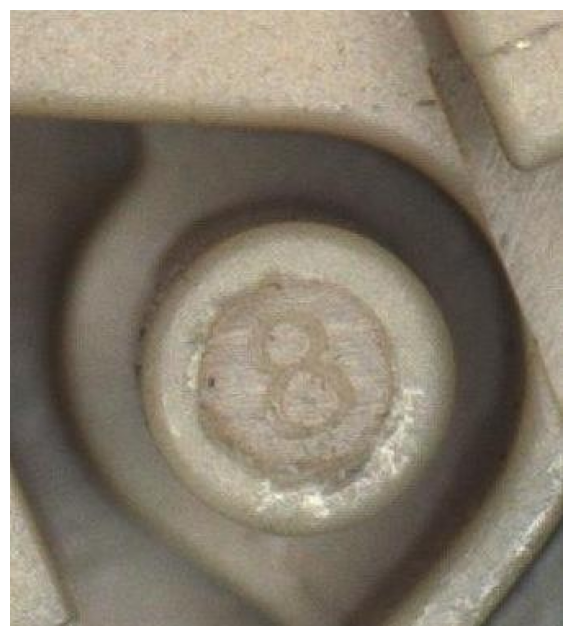


Predicted class: not_okay


In [36]:
import supervision as sv

input_file = "/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/test/not_okay/0495@View-001@2020-12-1_8-30-44.jpg_Part-0003.jpg"

new_image = load_image(input_file)

%matplotlib inline
sv.plot_image(image=cv2.imread(input_file), size=(8, 8))

with torch.no_grad():
    embedding = dinov2_vits14(new_image.to(device))

    prediction = clf.predict(np.array(embedding[0].cpu()).reshape(1, -1))

    print()
    print("Predicted class: " + prediction[0])

In [13]:
labels_test = {}

TEST_DIR = "C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/test/"

for folder in os.listdir(TEST_DIR):
    for file in os.listdir(os.path.join(TEST_DIR, folder)):
        if file.endswith(".jpg"):
            full_name = os.path.join(TEST_DIR, folder, file)
            labels_test[full_name] = folder

In [14]:
labels_test

{'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/test/not_okay\\0003@View-001@2020-09-29_10-23-12.jpg.jpg_Part-0002.jpg': 'not_okay',
 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/test/not_okay\\0003@View-001@2020-09-29_10-23-12.jpg.jpg_Part-0003.jpg': 'not_okay',
 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/test/not_okay\\0004@View-001@2020-09-29_10-23-12.jpg.jpg_Part-0002.jpg': 'not_okay',
 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/test/not_okay\\0004@View-001@2020-09-29_10-23-12.jpg.jpg_Part-0003.jpg': 'not_okay',
 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/test/not_okay\\0050@View-001@2020-10-6_9-30-17.jpg_Part-0003.jpg': 'not_okay',
 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/

In [45]:
len(labels_test)

793

In [15]:
labels_test_key = list(labels_test.keys())

In [16]:
labels_test_key

['C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/test/not_okay\\0003@View-001@2020-09-29_10-23-12.jpg.jpg_Part-0002.jpg',
 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/test/not_okay\\0003@View-001@2020-09-29_10-23-12.jpg.jpg_Part-0003.jpg',
 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/test/not_okay\\0004@View-001@2020-09-29_10-23-12.jpg.jpg_Part-0002.jpg',
 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/test/not_okay\\0004@View-001@2020-09-29_10-23-12.jpg.jpg_Part-0003.jpg',
 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/test/not_okay\\0050@View-001@2020-10-6_9-30-17.jpg_Part-0003.jpg',
 'C:/Users/resu/Desktop/FAPS - AI Project/datasets/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Part A/test/not_okay\\0052@View-001@2020-10-6_9-

In [17]:
predicted_test_key = [] 

for i in range(len(labels_test_key)):
    input_file = labels_test_key[i]

    new_image = load_image(input_file)

    %matplotlib inline
    #sv.plot_image(image=cv2.imread(input_file), size=(8, 8))

    with torch.no_grad():
        embedding = dinov2_vits14(new_image.to(device))

        prediction = clf.predict(np.array(embedding[0].cpu()).reshape(1, -1))

        print()
        print("Predicted class: " + prediction[0])
        predicted_test_key.append(prediction[0])

NameError: name 'load_image' is not defined

In [61]:
predicted_test

['okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 

In [63]:
labels_test_val = list(labels_test.values())

In [65]:
labels_test_val

['okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 'okay',
 

In [79]:
TP = 0 
TN = 0 
FP = 0 
FN = 0 



for i in range(len(labels_test_val)):
    if (labels_test_val[i] == 'okay' and predicted_test[i] == "okay"):
        TP+=1
    elif labels_test_val[i] == "not_okay" and predicted_test[i]=="not_okay":
        TN+=1 
    elif labels_test_val[i]=="not_okay" and predicted_test[i]=="okay":
        FP+=1 
    elif labels_test_val[i]=="okay" and predicted_test[i]=="not_okay":
        FN+=1 


print("TP:", TN, "\tFP:", FP, "\nFN:", FN, "\tTP:", TP)
        

TP: 196 	FP: 2 
FN: 0 	TP: 595


In [73]:
print(labels_test_val[0])

<class 'str'>
